In [14]:
#QUESTION1

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel('/Users/eshwar/Downloads/MACHINE HEALTH & MAINTENANCE.xlsx')


# Preprocessing


# One-hot encoding for categorical variables
df = pd.get_dummies(df, columns=['Plant', 'MachineID'], drop_first=True)

# Features and target
X = df[['Temperature', 'Vibration', 'Pressure', 'EnergyConsumption', 'ProductionUnits'] + 
       [col for col in df.columns if 'Plant_' in col or 'MachineID_' in col]]

y = df['DefectCount']


# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Model Training

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


# Predictions

y_pred = model.predict(X_test)


# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 1.3806316797917197
RMSE: 1.7525690722280474


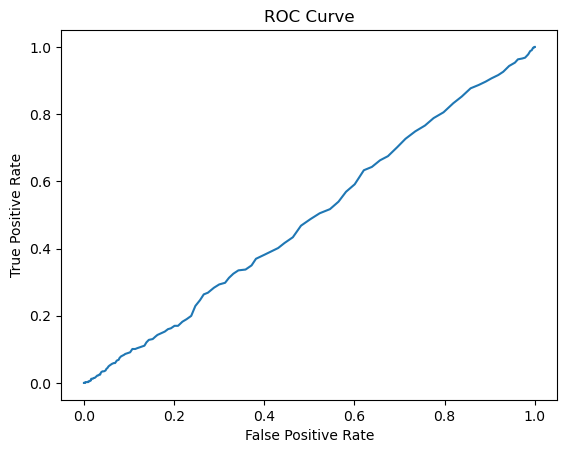

AUC: 0.49227023144759596


In [20]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc)


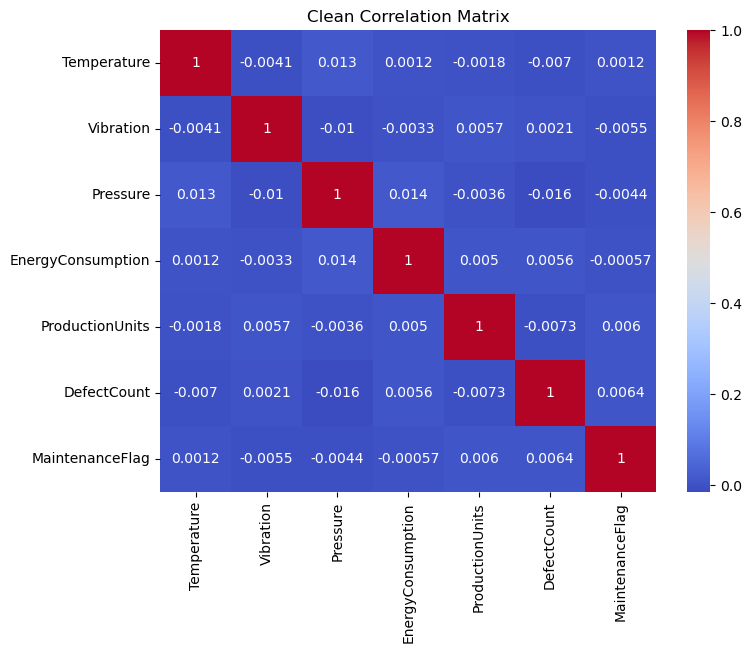

In [24]:
cols = ['Temperature', 'Vibration', 'Pressure', 
        'EnergyConsumption', 'ProductionUnits', 
        'DefectCount', 'MaintenanceFlag']

corr = df[cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Clean Correlation Matrix")
plt.show()


In [37]:
#question2



import pandas as pd
import numpy as np

df = pd.read_excel('/Users/eshwar/Downloads/MACHINE HEALTH & MAINTENANCE.xlsx')

# Encode categorical
df = pd.get_dummies(df, columns=['Plant', 'MachineID'], drop_first=True)

X = df.drop(['MaintenanceFlag', 'Timestamp'], axis=1)
y = df['MaintenanceFlag']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle imbalance (IMPORTANT)
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [40]:
#modeltraining
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_res, y_train_res)


RandomForestClassifier(n_estimators=200, random_state=42)

In [42]:
y_prob = model.predict_proba(X_test)[:, 1]

# Lower threshold (VERY IMPORTANT)
y_pred = (y_prob > 0.3).astype(int)


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Precision: 0.08603351955307263
Recall: 0.1896551724137931
F1 Score: 0.11837048424289008


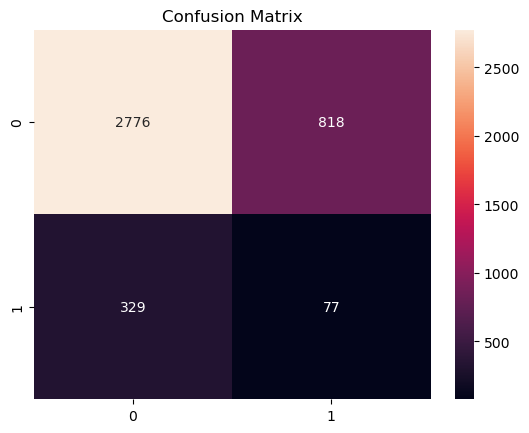

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


In [48]:
risk_df = X_test.copy()
risk_df['Actual'] = y_test.values
risk_df['Predicted_Prob'] = y_prob

top20 = risk_df.sort_values(by='Predicted_Prob', ascending=False).head(20)

print(top20)


       Temperature  Vibration   Pressure  EnergyConsumption  ProductionUnits  \
12243    76.150814   3.923481  31.963588         261.550268              102   
7353     64.576206   5.160791  28.634279         211.565717              181   
19141    60.005982   5.135170  30.336371         230.865988              198   
17283    82.491999   6.592327  31.469002         252.497489              150   
19314    79.032560   1.818393  30.838002         244.690797               54   
19006    71.717789   5.209387  31.960783         205.764520               55   
9132     75.904942   3.056718  28.212815         168.834835              163   
13549    72.320191   4.972120  34.683529         271.692315               57   
4074     72.289129   5.607430  28.169928         255.470391              142   
16368    56.682245   4.706082  31.408331         288.178522              107   
19603    76.745710   6.074372  27.304500         297.099862              157   
1256     72.119238   4.156333  27.644685

In [52]:
# Keep original data BEFORE encoding
df_original = pd.read_excel('/Users/eshwar/Downloads/MACHINE HEALTH & MAINTENANCE.xlsx')

# After model prediction
risk_df = X_test.copy()
risk_df['Actual'] = y_test.values
risk_df['Predicted_Prob'] = y_prob

# Add back original columns (Plant & MachineID)
risk_df['Plant'] = df_original.loc[risk_df.index, 'Plant']
risk_df['MachineID'] = df_original.loc[risk_df.index, 'MachineID']

# Get Top 20
top20 = risk_df.sort_values(by='Predicted_Prob', ascending=False).head(20)

print(top20[['Plant', 'MachineID', 'Predicted_Prob', 'Actual']])


         Plant  MachineID  Predicted_Prob  Actual
12243  Plant_C        124           0.840       0
7353   Plant_C        136           0.745       0
19141  Plant_A        115           0.730       0
17283  Plant_C        147           0.730       0
19314  Plant_C        116           0.725       0
19006  Plant_C        106           0.715       0
9132   Plant_B        127           0.705       0
13549  Plant_B        148           0.695       0
4074   Plant_B        106           0.690       0
16368  Plant_C        102           0.690       0
19603  Plant_B        104           0.680       0
1256   Plant_C        126           0.680       1
6901   Plant_C        111           0.675       0
14650  Plant_C        102           0.670       0
323    Plant_B        103           0.665       0
6714   Plant_B        111           0.660       0
18528  Plant_B        143           0.660       0
19848  Plant_C        114           0.655       0
2804   Plant_C        124           0.650       0
